#Machine Learning com dados de Saúde Mental em TI

##O presente estudo objetiva realizar o treinamento de um modelo de Machine Learning capaz de prever com acurácia satisfatória a tendência de um profissional de TI buscar ajuda profissional em questões de saúde mental

Conteúdo das colunas:
- Age
  
- Gender

- Country

- self_employed: "Você trabalha por conta própria?"

- family_history: "Você tem histórico familiar de doença mental?"

- treatment: "Você já procurou tratamento para alguma condição de saúde mental?"

- work_interfere: "Se você tiver uma condição mental, você sente que isso interfere no seu trabalho?"

- no_employees: "Quantos colaboradores sua companhia possui?"

- remote_work: "Você trabalha remotamente pelo menos 50% do tempo?"

- tech_company: "Seu empregador é primariamente uma organização de tecnologia?"

- benefits: "Seu empregador oferta benefícios na área de saúde mental?"

- care_options: "Você conhece os recursos para saúde mental que seu empregador oferece?"

- wellness_program: "Seu empregador já discutiu saúde mental como parte de um programa de bem-estar do colaborador?"

- seek_help: "Seu empregador oferece recursos para aprender mais sobre dificuldades na área de saúde mental e sobre como procurar ajuda?"

- anonymity: "O seu anonimato é protegido se você optar por aproveitar recursos de tratamento de saúde mental ou abuso de substâncias?" 

- leave: "O quão fácil é para você se afastar do trabalho por alguma condição de saúde mental?"

- mental_health_consequence: "Você acha que discutir um problema de saúde mental com seu empregador traria consequências negativas?"

- phys_health_consequence: "Você acha que discutir um problema de saúde física com seu empregador traria consequências negativas?"

- coworkers: "Você estaria disposto(a) a discutir um problema de saúde mental com seus colegas de trabalho?"

- supervisor: "Você estaria disposto(a) a discutir um problema de saúde mental com seu(s) supervisor(es) direto(s)?"

- mental_health_interview: "Você mencionaria um problema de saúde mental para um potencial empregador em uma entrevista?"

- phys_health_interview: "Você mencionaria um problema de saúde física para um potencial empregador em uma entrevista?"

- mental_vs_physical: "Você sente que seu empregador leva a saúde mental tão a sério quanto a saúde física?"

- obs_consequence: "Você já ouviu falar ou observou consequências negativas para colegas de trabalho com condições de saúde mental em seu local de trabalho?"


Importação das libs que serão utilizadas no projeto

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import mean

Leitura do dataset em .csv com pandas

In [35]:
df = pd.read_csv("survey.csv")

Primeira exibição para análise exploratória do dataset

In [36]:
display(df)

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN


###Início do tratamento dos dados

1) Remoção das colunas "Timestamp", "state" e "comments" 

In [37]:
df.drop("Timestamp", axis=1, inplace=True)
df.drop("state", axis=1, inplace=True)
df.drop("comments", axis=1, inplace=True)

2) Tratamento da idade para valores >= 18 e <= 100

In [38]:
df = df[df["Age"] >= 18]
df = df[df["Age"] <= 100]

3) Tratamento da coluna de gêneros

    Male = 1
    Female = 2
    Others = 3

In [39]:
df["Gender"] = df["Gender"].str.strip().str.upper()
valores_troca_MALE = ["M", "MAKE", "MAN", "MALE", "MAL", "MALR", "MAIL", "MSLE", "MAILE", "GUY (-ISH) ^_^","CIS MALE", 
                 "CIS MAN", "MALE LEANING ANDROGYNOUS", "SOMETHING KINDA MALE?", "OSTENSIBLY MALE, UNSURE WHAT THAT REALLY MEANS","MALE-ISH", "MALE (CIS)"]
df["Gender"] = df["Gender"].replace(valores_troca_MALE, 1)



valores_troca_FEMALE = ["F", "WOMAN", "FEMALE (TRANS)", "FEMAIL", "FEMALE", "TRANS WOMAN", "TRANS-FEMALE", 
                        "CIS-FEMALE/FEMME", "CIS FEMALE", "FEMAKE","FEMALE (CIS)"]
df["Gender"] = df["Gender"].replace(valores_troca_FEMALE, 2)



permitidos = [1, 2]
df.loc[~df["Gender"].isin(permitidos), "Gender"] = 3


In [40]:
## Percorrimento das colunas para contagem de cada um dos valores e análise
for i in df.columns:
    valores = df[i].value_counts()
    print(valores, "\n")

Age
29    85
32    82
26    75
27    71
33    70
28    68
31    67
34    65
30    63
25    61
35    55
23    51
24    46
37    43
38    39
36    37
39    33
40    33
43    28
41    21
22    21
42    20
21    16
45    12
46    12
44    11
19     9
18     7
48     6
50     6
20     6
51     5
49     4
56     4
55     3
57     3
54     3
47     2
60     2
58     1
62     1
65     1
53     1
61     1
72     1
Name: count, dtype: int64 

Gender
1    990
2    251
3     10
Name: count, dtype: int64 

Country
United States             746
United Kingdom            184
Canada                     72
Germany                    45
Netherlands                27
Ireland                    27
Australia                  21
France                     13
India                      10
New Zealand                 8
Italy                       7
Poland                      7
Sweden                      7
Switzerland                 7
South Africa                6
Belgium                     6
Brazil       

4. Tratamento da coluna "Country"

   Usando o método 'factorize' do Pandas para converter os países em valores numéricos

In [41]:
df['Country'] = pd.factorize(df['Country'])[0]
print(df['Country'])

0       0
1       0
2       1
3       2
4       0
       ..
1254    2
1255    0
1256    0
1257    0
1258    0
Name: Country, Length: 1251, dtype: int64


5) Tratamento da coluna de número de colaboradores na empresa do entrevistado

In [42]:
df.loc[df['no_employees'] == "1-5", 'no_employees'] = 0
df.loc[df['no_employees'] == "6-25", 'no_employees'] = 1
df.loc[df['no_employees'] == "26-100", 'no_employees'] = 2
df.loc[df['no_employees'] == "100-500", 'no_employees'] = 3
df.loc[df['no_employees'] == "500-1000", 'no_employees'] = 4
df.loc[df['no_employees'] == "More than 1000", 'no_employees'] = 5

6) Transformação das colunas com dados dicotômicos (sim ou não)

   Colunas: 'self_employed', 'family_history', 'treatment', 'remote_work', 'tech_company', 'obs_consequence'

In [43]:
colunas_dicotomicas = {'self_employed', 'family_history', 'treatment', 'remote_work', 'tech_company', 'obs_consequence'}
tratamento = {'Yes':1, 'No':0}

for i in colunas_dicotomicas:
    df[i] = df[i].map(tratamento)

df['self_employed'] = df['self_employed'].astype('Int64')
df.fillna({'self_employed':0}, inplace=True)

df['family_history'] = df['family_history'].astype('Int64')
df['treatment'] = df['treatment'].astype('Int64')
df['remote_work'] = df['remote_work'].astype('Int64')
df['tech_company'] = df['tech_company'].astype('Int64')
df['obs_consequence'] = df['obs_consequence'].astype('Int64')

display(df)

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,2,0,0,0,1,Often,1,0,1,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,0
1,44,1,0,0,0,0,Rarely,5,0,0,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,0
2,32,1,1,0,0,0,Rarely,1,0,1,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,0
3,31,1,2,0,1,1,Often,2,0,1,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,1
4,31,1,0,0,0,0,Never,3,1,1,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,26,1,2,0,0,1,NaN,2,0,1,...,Don't know,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,0
1255,32,1,0,0,1,1,Often,2,1,1,...,Yes,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,0
1256,34,1,0,0,1,1,Sometimes,5,0,1,...,Don't know,Somewhat difficult,Yes,Yes,No,No,No,No,No,0
1257,46,2,0,0,0,0,NaN,3,1,1,...,Don't know,Don't know,Yes,No,No,No,No,No,No,0


7) Transformação das colunas com dados ordinais (hierarquia)

   Colunas: 'work_interfere', 'no_employees', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview, 'phys_health_interview', 'mental_vs_physical'

In [44]:
escala_work_interfere = {'Never':1, 'Rarely':2, 'Sometimes':3, 'Often':4}
escala_leave = {"Don't know":0, 'Somewhat easy':1, 'Very easy':2, 'Somewhat difficult':3, 'Very difficult':4}
escala_geral = {'No':0, "Don't know":1, 'Not Sure':2, 'Maybe':3, 'Some of them':4, 'Yes':5}

df['work_interfere'] = df['work_interfere'].map(escala_work_interfere)
df.fillna({'work_interfere': 0}, inplace=True)
df['work_interfere'] = df['work_interfere'].astype(int)

df['leave'] = df['leave'].map(escala_leave)


colunas_restantes = {'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'mental_health_consequence', 
                     'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical'}


for i in colunas_restantes:
    df[i] = df[i].map(escala_geral)

display(df)

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,2,0,0,0,1,4,1,0,1,...,5,1,0,0,4,5,0,3,5,0
1,44,1,0,0,0,0,2,5,0,0,...,1,0,3,0,0,0,0,0,1,0
2,32,1,1,0,0,0,2,1,0,1,...,1,3,0,0,5,5,5,5,0,0
3,31,1,2,0,1,1,4,2,0,1,...,0,3,5,5,4,0,3,3,0,1
4,31,1,0,0,0,0,1,3,1,1,...,1,0,0,0,4,5,5,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,26,1,2,0,0,1,0,2,0,1,...,1,1,0,0,4,4,0,0,1,0
1255,32,1,0,0,1,1,4,2,1,1,...,5,3,0,0,4,5,0,0,5,0
1256,34,1,0,0,1,1,3,5,0,1,...,1,3,5,5,0,0,0,0,0,0
1257,46,2,0,0,0,0,0,3,1,1,...,1,0,5,0,0,0,0,0,0,0


Verificação de valores NaN ainda não tratados

In [45]:
df.isna().sum()

Age                            0
Gender                         0
Country                        0
self_employed                  0
family_history                 0
treatment                      0
work_interfere                 0
no_employees                   0
remote_work                    0
tech_company                   0
benefits                       0
care_options                 313
wellness_program               0
seek_help                      0
anonymity                      0
leave                          0
mental_health_consequence      0
phys_health_consequence        0
coworkers                      0
supervisor                     0
mental_health_interview        0
phys_health_interview          0
mental_vs_physical             0
obs_consequence                0
dtype: int64

Preenchendo valores nulos com '0'

In [46]:
df.fillna(0, inplace=True)

###Análise dos atributos contidos no Dataset

Criação da matriz de correlação de Pearson

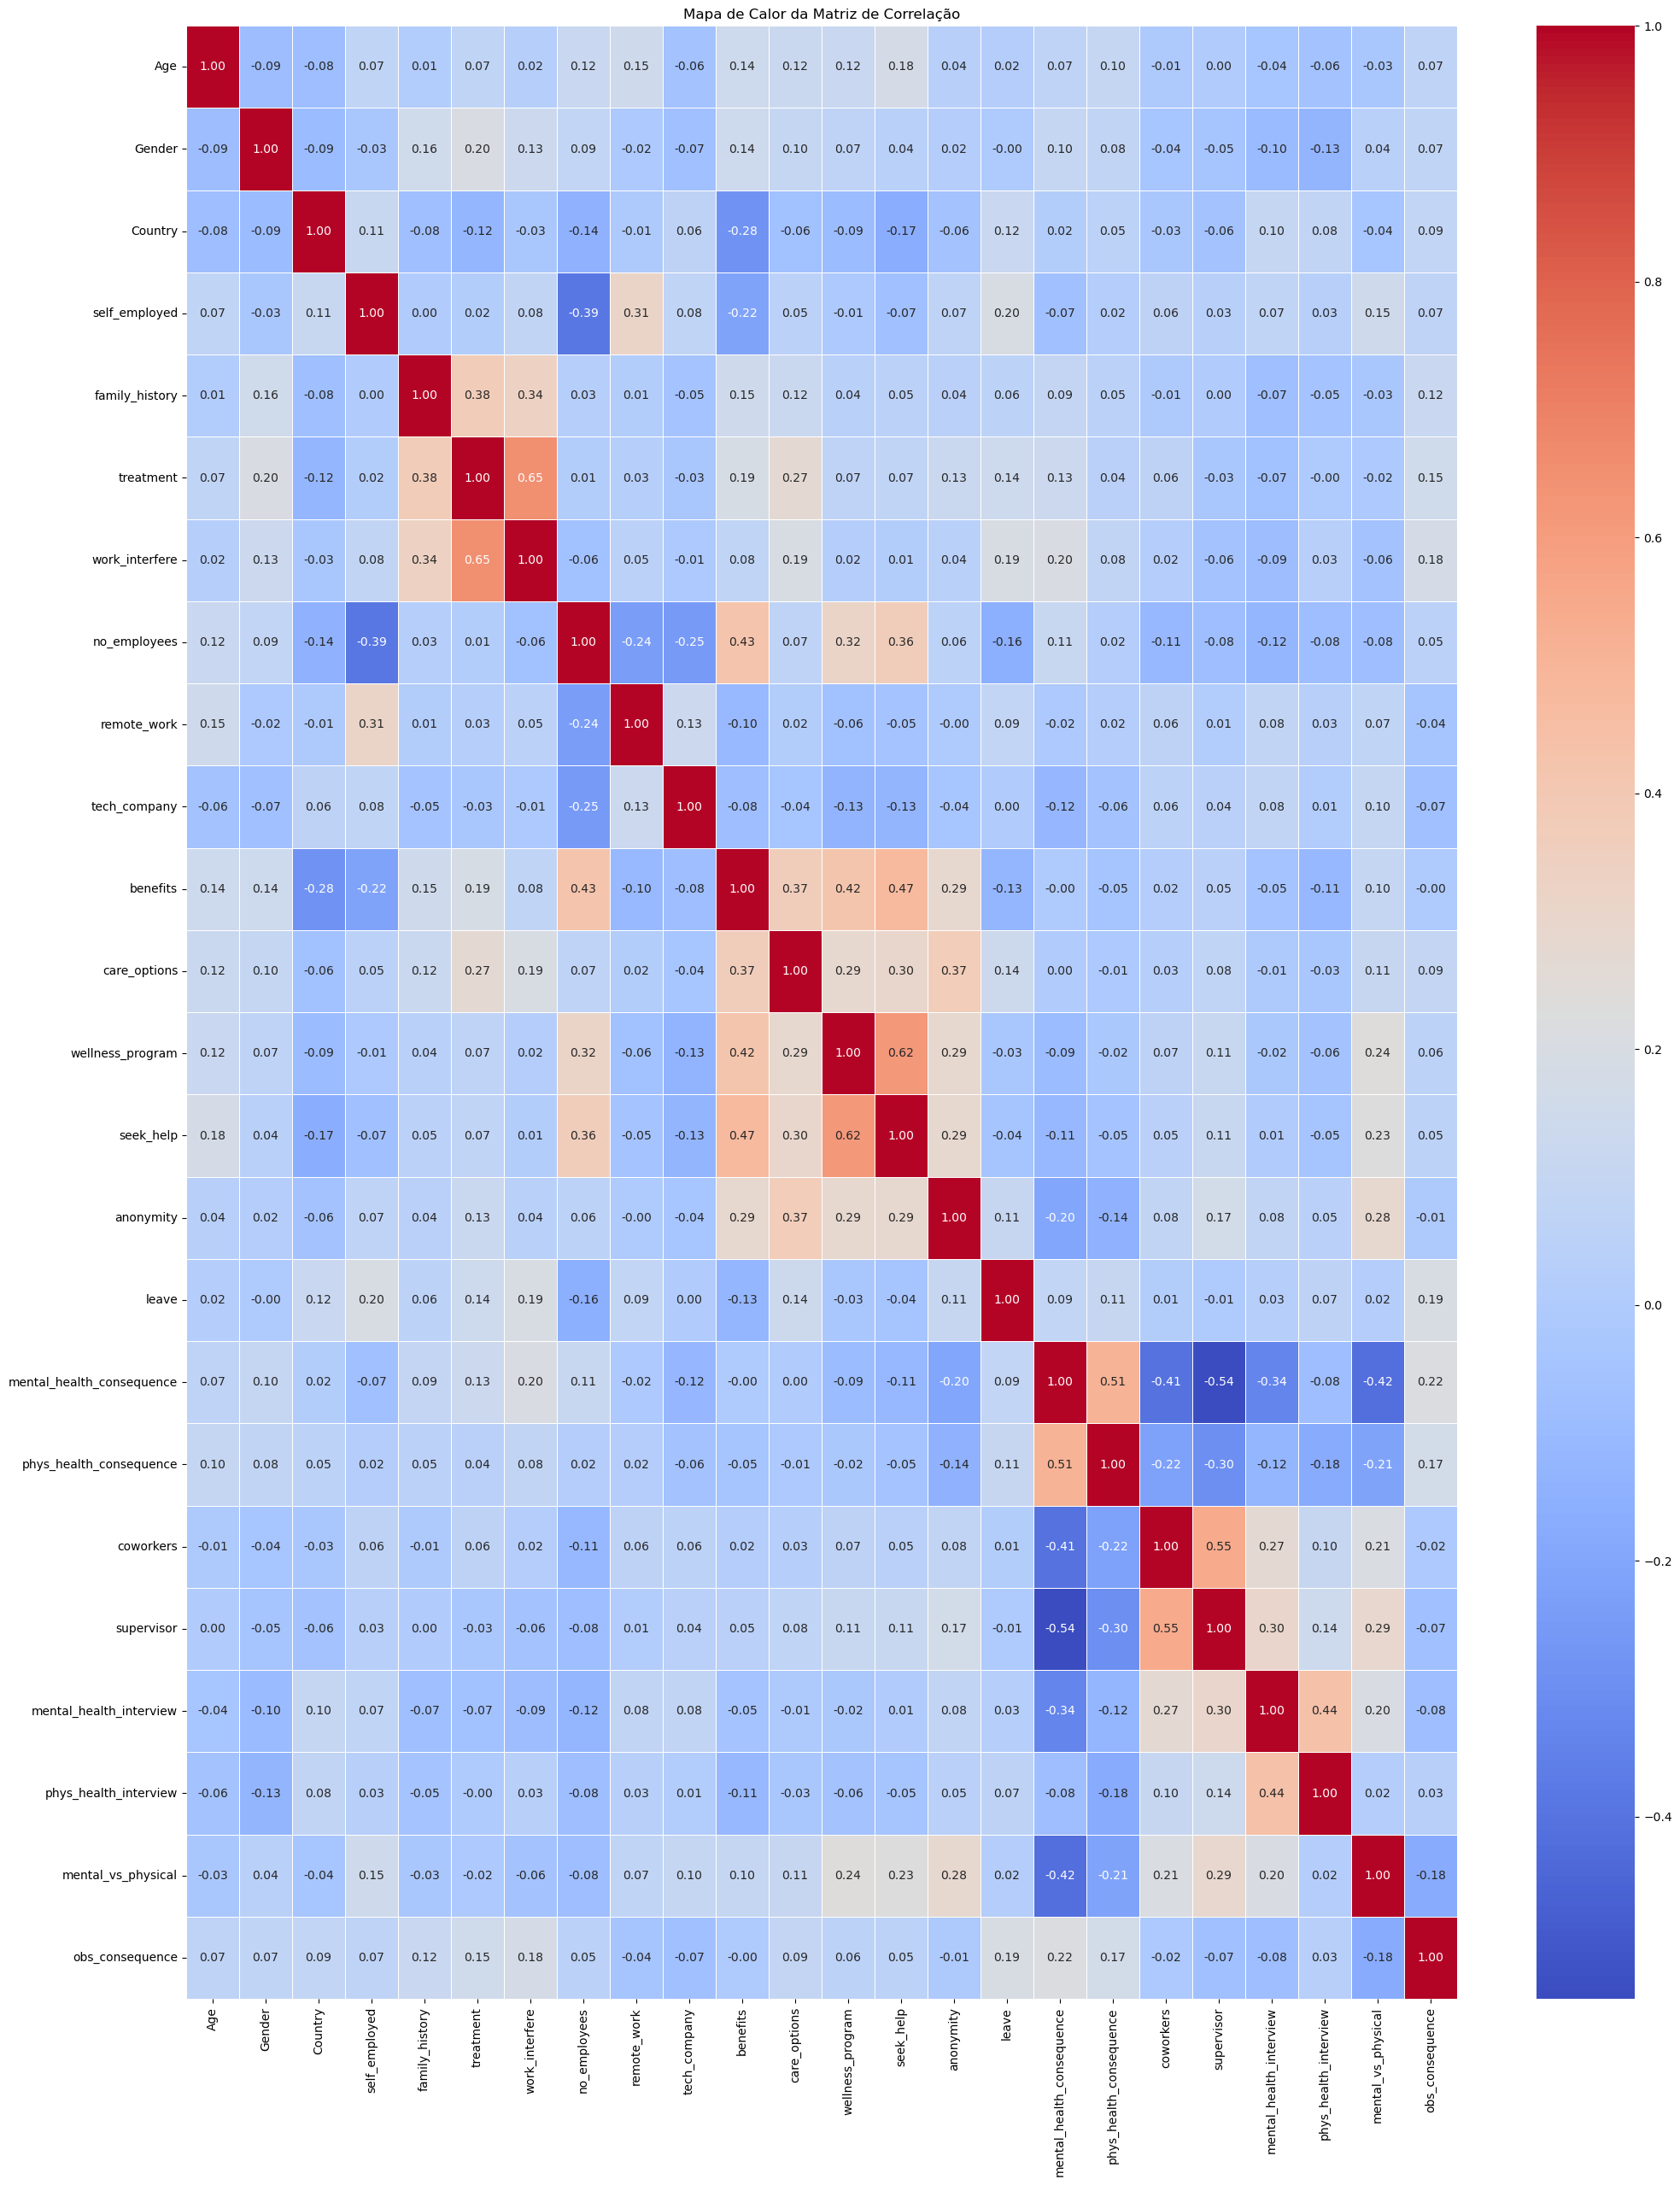

In [47]:
matriz_correlacao_pearson = df.corr()

plt.figure(figsize=(24,30))

sns.heatmap(
    matriz_correlacao_pearson,
    annot=True,     # Mostra os valores numéricos na célula
    cmap='coolwarm',
    fmt=".2f",      # Formata os números com 2 casas decimais
    linewidths=.5,  # Linhas entre as células
    cbar=True       # Mostra a barra de cores
)

## Comando de criação do título da figura e comando de exibição na tela ##
plt.title('Mapa de Calor da Matriz de Correlação')
plt.show()

Criação da matriz de correlação de Pearson

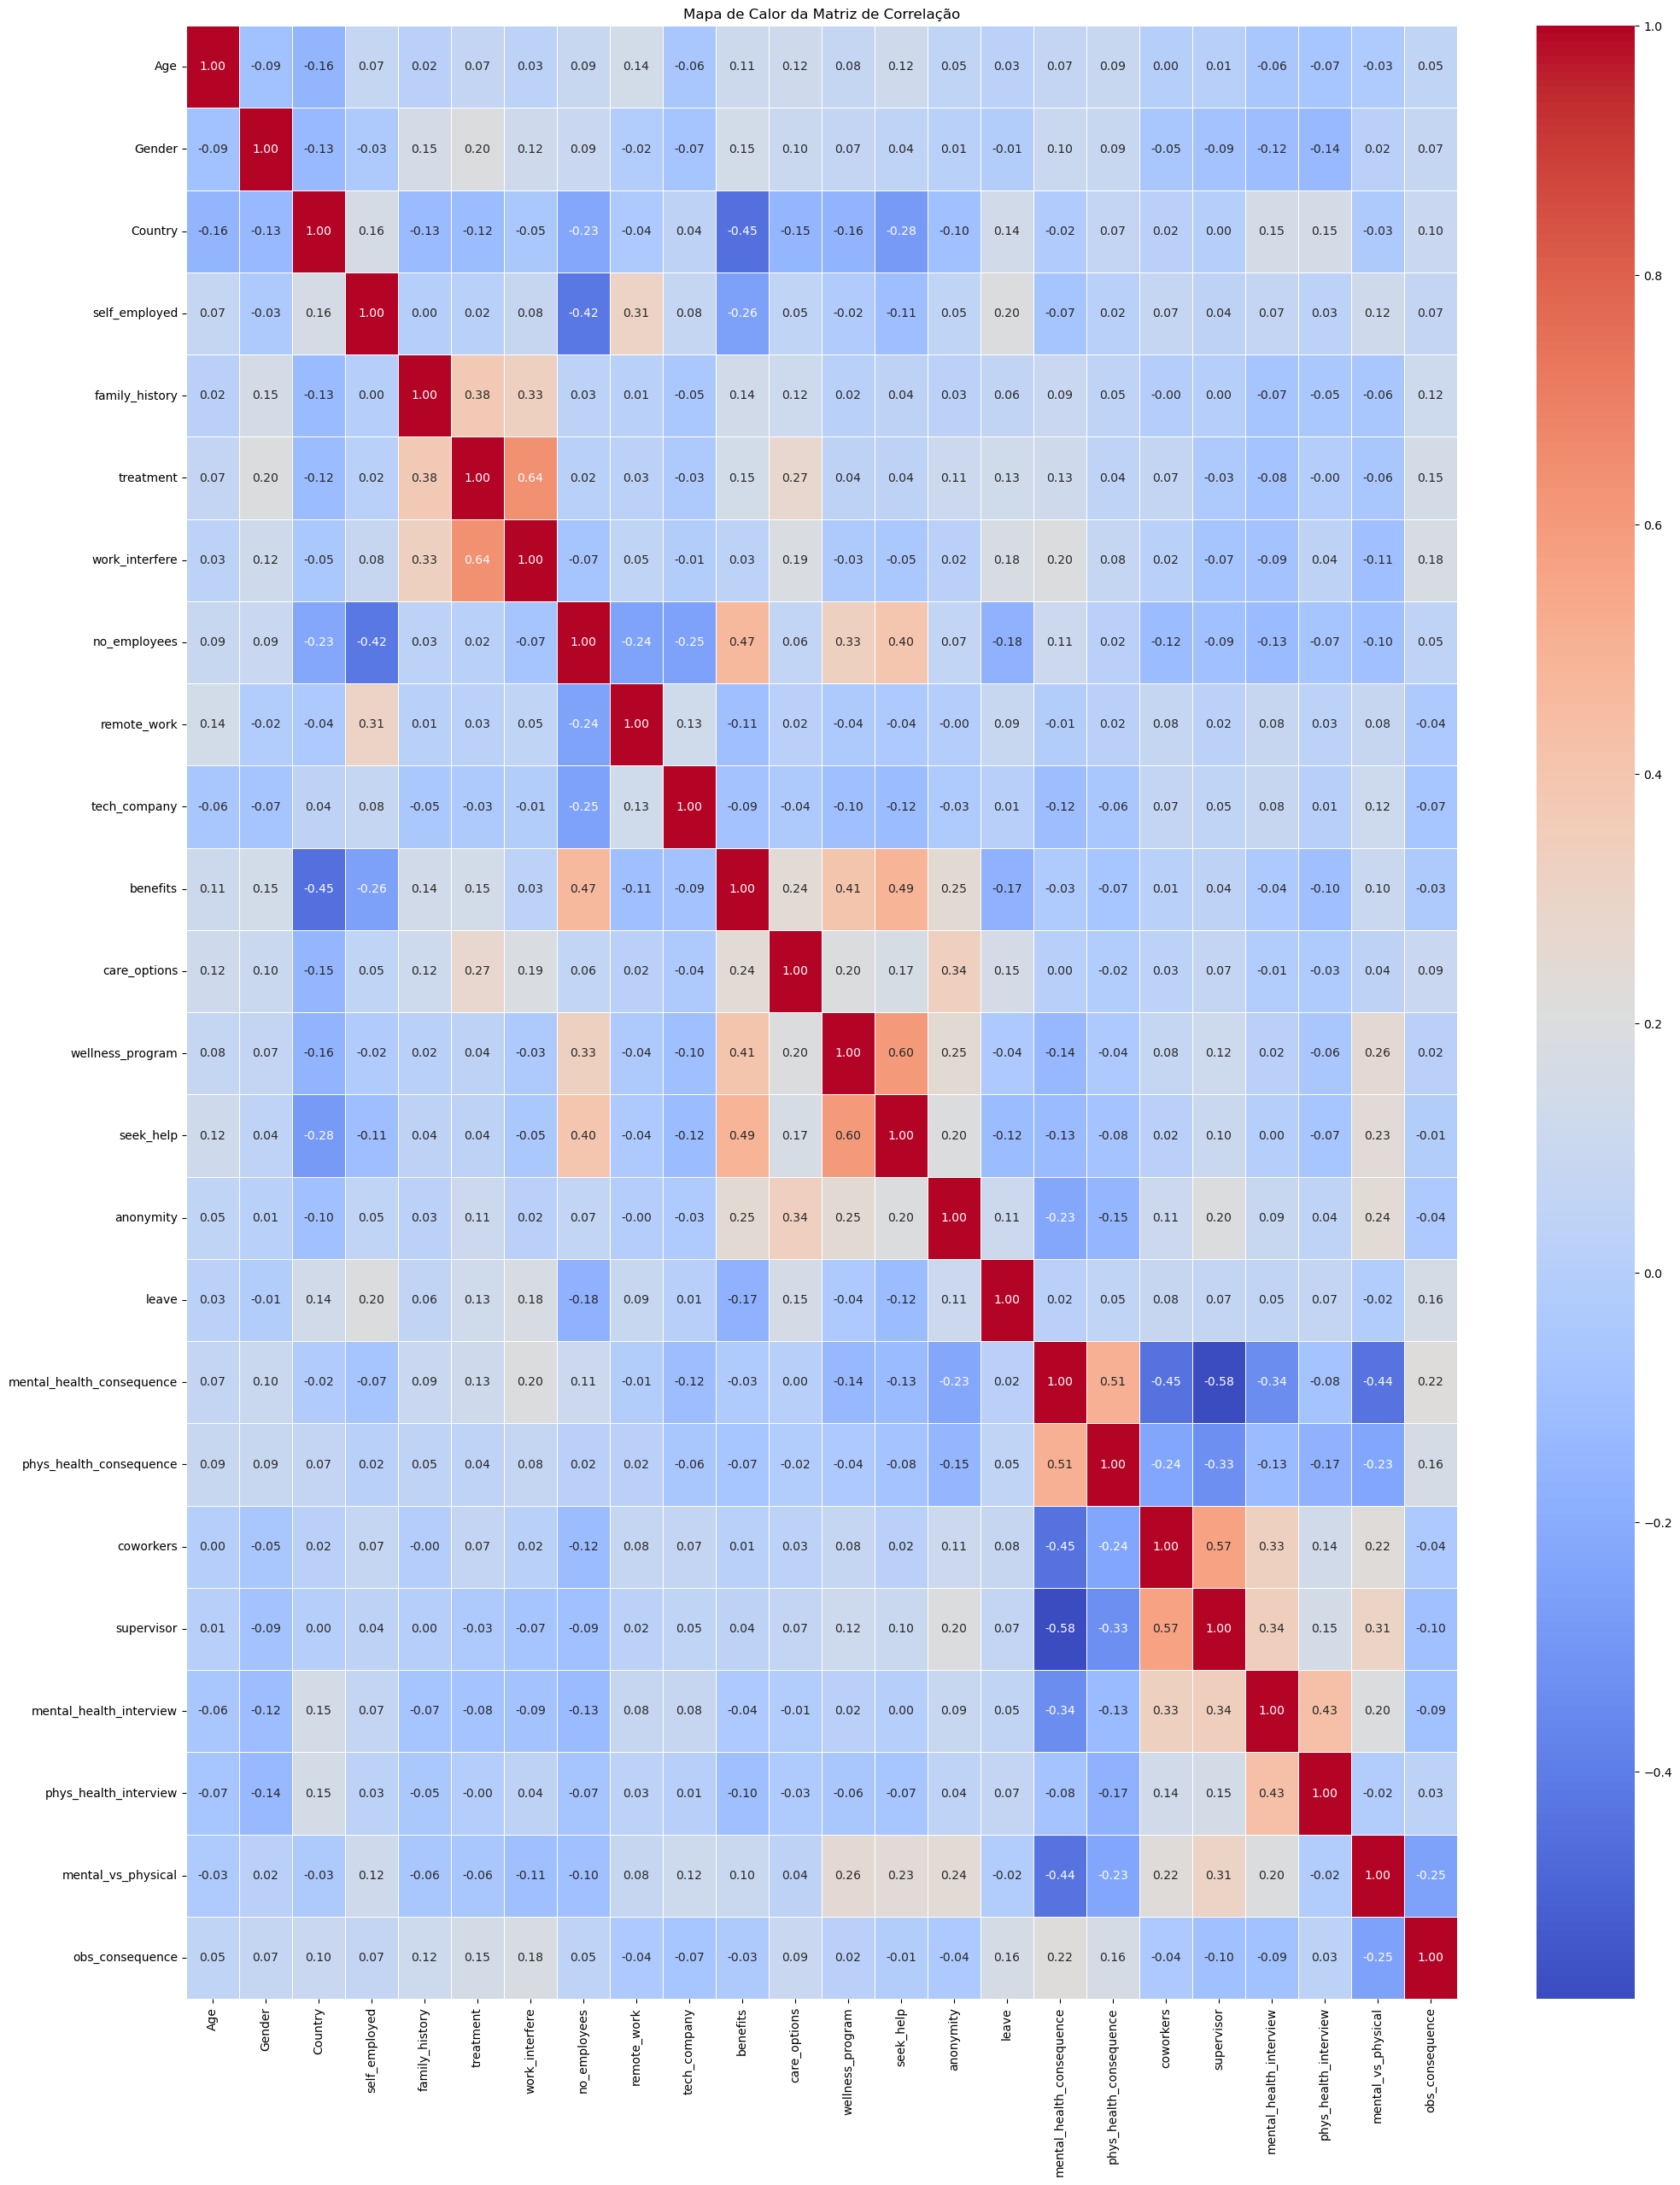

In [48]:
matriz_correlacao_spearman = df.corr(method='spearman')

plt.figure(figsize=(24,30))

sns.heatmap(
    matriz_correlacao_spearman,
    annot=True,     # Mostra os valores numéricos na célula
    cmap='coolwarm',
    fmt=".2f",      # Formata os números com 2 casas decimais
    linewidths=.5,  # Linhas entre as células
    cbar=True       # Mostra a barra de cores
)

## Comando de criação do título da figura e comando de exibição na tela ##
plt.title('Mapa de Calor da Matriz de Correlação')
plt.show()

Análise dos atributos com um método nativo da classe RandomForestClassifier

In [49]:
X = df.drop(columns=['treatment'])
y = df['treatment']

print(X)
print(y)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, stratify= y, shuffle= True, random_state= None)
myrf_all = RandomForestClassifier(n_estimators=100)
myrf_all.fit(X_treino, y_treino)

importances = pd.Series(myrf_all.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

      Age Gender  Country  self_employed  family_history  work_interfere  \
0      37      2        0              0               0               4   
1      44      1        0              0               0               2   
2      32      1        1              0               0               2   
3      31      1        2              0               1               4   
4      31      1        0              0               0               1   
...   ...    ...      ...            ...             ...             ...   
1254   26      1        2              0               0               0   
1255   32      1        0              0               1               4   
1256   34      1        0              0               1               3   
1257   46      2        0              0               0               0   
1258   25      1        0              0               1               3   

     no_employees  remote_work  tech_company  benefits  ...  anonymity  leave  \
0     

###Início do treinamento dos modelos

Modelo de Teste N° 0 - Todos os atributos

In [50]:
X = df.drop(columns=['treatment'])
y = df['treatment']

print(X)
print(y)

score_result_all = []

for i in range(1000):
    X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, stratify= y, shuffle= True, random_state= None)
    myrf_all = RandomForestClassifier(n_estimators=100)
    myrf_all.fit(X_treino, y_treino)
    score = myrf_all.score(X_teste, y_teste)
    score_result_all.append(score)

print("\n",score_result_all)

      Age Gender  Country  self_employed  family_history  work_interfere  \
0      37      2        0              0               0               4   
1      44      1        0              0               0               2   
2      32      1        1              0               0               2   
3      31      1        2              0               1               4   
4      31      1        0              0               0               1   
...   ...    ...      ...            ...             ...             ...   
1254   26      1        2              0               0               0   
1255   32      1        0              0               1               4   
1256   34      1        0              0               1               3   
1257   46      2        0              0               0               0   
1258   25      1        0              0               1               3   

     no_employees  remote_work  tech_company  benefits  ...  anonymity  leave  \
0     

Modelo de Teste N° 1 - Trabalhando apenas com o atributo 'work_interfere'

In [51]:
X_modelo1 = df.drop(columns=['Age', 'Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados do atributo utilizado (work_interfere): ")
print(X_modelo1)
y = df['treatment']
print(y)

resultados_modelo1 = []

for i in range(1000):
    X_treino_Modelo1, X_teste_Modelo1, y_treino_Modelo1, y_teste_Modelo1 = train_test_split(X_modelo1, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo1 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo1.fit(X_treino_Modelo1, y_treino_Modelo1)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo1 = myrf_modelo1.score(X_teste_Modelo1, y_teste_Modelo1)
    #print("Rf_modelo1\n", randomf_modelo1)
    resultados_modelo1.append(randomf_modelo1)

print("\n",resultados_modelo1)


 Dados do atributo utilizado (work_interfere): 
      work_interfere
0                  4
1                  2
2                  2
3                  4
4                  1
...              ...
1254               0
1255               4
1256               3
1257               0
1258               3

[1251 rows x 1 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.8138297872340425, 0.8324468085106383, 0.851063829787234, 0.8297872340425532, 0.8430851063829787, 0.8537234042553191, 0.848404255319149, 0.8191489361702128, 0.8351063829787234, 0.8351063829787234, 0.8377659574468085, 0.8537234042553191, 0.8164893617021277, 0.8138297872340425, 0.8297872340425532, 0.8191489361702128, 0.8324468085106383, 0.824468085106383, 0.8191489361702128, 0.8297872340425532, 0.8191489361702128, 0.8031914893617021, 0.8377659574468085, 0.8218085106382979, 0.8377659574468085, 0.8218085106382979, 

Modelo de Teste N° 2 - Trabalhando apenas com o atributo 'family_history'

In [52]:
X_modelo2 = df.drop(columns=['Age', 'Gender', 'Country', 'self_employed', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados do atributo utilizado (family_history): ")
print(X_modelo2)
y = df['treatment']
print(y)

resultados_modelo2 = []

for i in range(1000):
    X_treino_Modelo2, X_teste_Modelo2, y_treino_Modelo2, y_teste_Modelo2 = train_test_split(X_modelo2, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo2 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo2.fit(X_treino_Modelo2, y_treino_Modelo2)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo2 = myrf_modelo2.score(X_teste_Modelo2, y_teste_Modelo2)
    #print("Rf_modelo2\n", randomf_modelo2)
    resultados_modelo2.append(randomf_modelo2)

print("\n",resultados_modelo2)


 Dados do atributo utilizado (family_history): 
      family_history
0                  0
1                  0
2                  0
3                  1
4                  0
...              ...
1254               0
1255               1
1256               1
1257               0
1258               1

[1251 rows x 1 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.6808510638297872, 0.6968085106382979, 0.7180851063829787, 0.7180851063829787, 0.6702127659574468, 0.6835106382978723, 0.6888297872340425, 0.6941489361702128, 0.6968085106382979, 0.6781914893617021, 0.7021276595744681, 0.6888297872340425, 0.6914893617021277, 0.6835106382978723, 0.6595744680851063, 0.6968085106382979, 0.675531914893617, 0.6728723404255319, 0.6675531914893617, 0.6861702127659575, 0.6781914893617021, 0.6914893617021277, 0.6835106382978723, 0.675531914893617, 0.6968085106382979, 0.7021276595744681,

Modelo de Teste N° 3 - Trabalhando apenas com os atributos 'work_interfere' + 'family_history'

In [53]:
X_modelo3 = df.drop(columns=['Age', 'Gender', 'Country', 'self_employed', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados dos atributos utilizados (work_interfere + family_history): ")
print(X_modelo3)
y = df['treatment']
print(y)

resultados_modelo3 = []

for i in range(1000):
    X_treino_Modelo3, X_teste_Modelo3, y_treino_Modelo3, y_teste_Modelo3 = train_test_split(X_modelo3, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo3 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo3.fit(X_treino_Modelo3, y_treino_Modelo3)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo3 = myrf_modelo3.score(X_teste_Modelo3, y_teste_Modelo3)
    #print("Rf_modelo3\n", randomf_modelo3)
    resultados_modelo3.append(randomf_modelo3)

print("\n",resultados_modelo3)


 Dados dos atributos utilizados (work_interfere + family_history): 
      family_history  work_interfere
0                  0               4
1                  0               2
2                  0               2
3                  1               4
4                  0               1
...              ...             ...
1254               0               0
1255               1               4
1256               1               3
1257               0               0
1258               1               3

[1251 rows x 2 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.848404255319149, 0.8191489361702128, 0.8297872340425532, 0.8457446808510638, 0.8164893617021277, 0.8617021276595744, 0.8271276595744681, 0.8351063829787234, 0.8537234042553191, 0.8670212765957447, 0.8271276595744681, 0.8457446808510638, 0.800531914893617, 0.8164893617021277, 0.8111702127659575, 0.82978

Modelo de Teste N° 4 - Trabalhando apenas com os atributos 'work_interfere' + 'mental_health_consequence'

In [54]:
X_modelo4 = df.drop(columns=['Age', 'Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados dos atributos utilizados (work_interfere + mental_health_consequence): ")
print(X_modelo4)
y = df['treatment']
print(y)

resultados_modelo4 = []

for i in range(1000):
    X_treino_Modelo4, X_teste_Modelo4, y_treino_Modelo4, y_teste_Modelo4 = train_test_split(X_modelo4, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo4 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo4.fit(X_treino_Modelo4, y_treino_Modelo4)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo4 = myrf_modelo4.score(X_teste_Modelo4, y_teste_Modelo4)
    #print("Rf_modelo4\n", randomf_modelo4)
    resultados_modelo4.append(randomf_modelo4)

print("\n",resultados_modelo4)


 Dados dos atributos utilizados (work_interfere + mental_health_consequence): 
      work_interfere  mental_health_consequence
0                  4                          0
1                  2                          3
2                  2                          0
3                  4                          5
4                  1                          0
...              ...                        ...
1254               0                          0
1255               4                          0
1256               3                          5
1257               0                          5
1258               3                          3

[1251 rows x 2 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.8563829787234043, 0.848404255319149, 0.8351063829787234, 0.8271276595744681, 0.8085106382978723, 0.8324468085106383, 0.8537234042553191, 0.8191489361702128, 0.8

Modelo de Teste N° 5 - Trabalhando apenas com os atributos 'family_history' + 'mental_health_consequence'

In [55]:
X_modelo5 = df.drop(columns=['Age', 'Gender', 'Country', 'self_employed', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados dos atributos utilizados (family_history + mental_health_consequence): ")
print(X_modelo5)
y = df['treatment']
print(y)

resultados_modelo5 = []

for i in range(1000):
    X_treino_Modelo5, X_teste_Modelo5, y_treino_Modelo5, y_teste_Modelo5 = train_test_split(X_modelo5, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo5 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo5.fit(X_treino_Modelo5, y_treino_Modelo5)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo5 = myrf_modelo5.score(X_teste_Modelo5, y_teste_Modelo5)
    #print("Rf_modelo5\n", randomf_modelo5)
    resultados_modelo5.append(randomf_modelo5)

print("\n",resultados_modelo5)


 Dados dos atributos utilizados (family_history + mental_health_consequence): 
      family_history  mental_health_consequence
0                  0                          0
1                  0                          3
2                  0                          0
3                  1                          5
4                  0                          0
...              ...                        ...
1254               0                          0
1255               1                          0
1256               1                          5
1257               0                          5
1258               1                          3

[1251 rows x 2 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.6835106382978723, 0.675531914893617, 0.6888297872340425, 0.699468085106383, 0.6728723404255319, 0.6622340425531915, 0.675531914893617, 0.6595744680851063, 0.696

Modelo de Teste N° 6 - Trabalhando apenas com os atributos 'work_interfere' + 'family_history' + 'mental_health_consequence'

In [56]:
X_modelo6 = df.drop(columns=['Age', 'Gender', 'Country', 'self_employed', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados dos atributos utilizados (work_interfere + family_history + mental_health_consequence): ")
print(X_modelo6)
y = df['treatment']
print(y)

resultados_modelo6 = []

for i in range(1000):
    X_treino_Modelo6, X_teste_Modelo6, y_treino_Modelo6, y_teste_Modelo6 = train_test_split(X_modelo6, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo6 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo6.fit(X_treino_Modelo6, y_treino_Modelo6)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo6 = myrf_modelo6.score(X_teste_Modelo6, y_teste_Modelo6)
    #print("Rf_modelo6\n", randomf_modelo6)
    resultados_modelo6.append(randomf_modelo6)

print("\n",resultados_modelo6)


 Dados dos atributos utilizados (work_interfere + family_history + mental_health_consequence): 
      family_history  work_interfere  mental_health_consequence
0                  0               4                          0
1                  0               2                          3
2                  0               2                          0
3                  1               4                          5
4                  0               1                          0
...              ...             ...                        ...
1254               0               0                          0
1255               1               4                          0
1256               1               3                          5
1257               0               0                          5
1258               1               3                          3

[1251 rows x 3 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1


Exibição das médias dos modelos de 1 a 5

In [57]:
print("\nO valor médio da Random Forest com todos os atributos", mean(score_result_all))
print("\n---------------------------")
print("\nO valor médio da Random Forest com o atributo work_interfere é:", mean(resultados_modelo1))
print("\n---------------------------")
print("\nO valor médio da Random Forest com o atributo family_history é:", mean(resultados_modelo2))
print("\n---------------------------")
print("\nO valor médio da Random Forest com os atributos work_interfere + family_history é:", mean(resultados_modelo3))
print("\n---------------------------")
print("\nO valor médio da Random Forest com os atributos work_interfere + mental_health_consequence é:", mean(resultados_modelo4))
print("\n---------------------------")
print("\nO valor médio da Random Forest com os atributos family_history + mental_health_consequence é:", mean(resultados_modelo5))
print("\n---------------------------")
print("\nO valor médio da Random Forest com os atributos work_interfere + family_history + mental_health_consequence é:", mean(resultados_modelo6))
print("\n---------------------------")


O valor médio da Random Forest com todos os atributos 0.8306755319148937

---------------------------

O valor médio da Random Forest com o atributo work_interfere é: 0.8309760638297873

---------------------------

O valor médio da Random Forest com o atributo family_history é: 0.6819920212765956

---------------------------

O valor médio da Random Forest com os atributos work_interfere + family_history é: 0.827622340425532

---------------------------

O valor médio da Random Forest com os atributos work_interfere + mental_health_consequence é: 0.82943085106383

---------------------------

O valor médio da Random Forest com os atributos family_history + mental_health_consequence é: 0.6824468085106382

---------------------------

O valor médio da Random Forest com os atributos work_interfere + family_history + mental_health_consequence é: 0.8224281914893617

---------------------------


###Análise 'work_interfere'

    Considerando que a variável supracitada demonstrou ser a mais impactante em todos os métodos de correlação aplicados e no treinamento dos modelos de predição para o target 'treatment', iremos realizar algumas análise comparativas com os demais atributos.

In [58]:
X = df.drop(columns=['treatment', 'work_interfere'])
y = df['work_interfere']

display(X)
print(y)

score_result = []

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, stratify= y, shuffle= True, random_state= None)
myrf_all = RandomForestClassifier(n_estimators=100)
myrf_all.fit(X_treino, y_treino)
importances = pd.Series(myrf_all.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

for i in range(1000):
    score = myrf_all.score(X_teste, y_teste)
    score_result.append(score)

print("\n",score_result)
print("\n", mean(score_result))

,Age,Gender,Country,self_employed,family_history,no_employees,remote_work,tech_company,benefits,care_options,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,2,0,0,0,1,0,1,5,0.0,...,5,1,0,0,4,5,0,3,5,0
1,44,1,0,0,0,5,0,0,1,0.0,...,1,0,3,0,0,0,0,0,1,0
2,32,1,1,0,0,1,0,1,0,0.0,...,1,3,0,0,5,5,5,5,0,0
3,31,1,2,0,1,2,0,1,0,5.0,...,0,3,5,5,4,0,3,3,0,1
4,31,1,0,0,0,3,1,1,5,0.0,...,1,0,0,0,4,5,5,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,26,1,2,0,0,2,0,1,0,0.0,...,1,1,0,0,4,4,0,0,1,0
1255,32,1,0,0,1,2,1,1,5,5.0,...,5,3,0,0,4,5,0,0,5,0
1256,34,1,0,0,1,5,0,1,5,5.0,...,1,3,5,5,0,0,0,0,0,0
1257,46,2,0,0,0,3,1,1,0,5.0,...,1,0,5,0,0,0,0,0,0,0


0       4
1       2
2       2
3       4
4       1
       ..
1254    0
1255    4
1256    3
1257    0
1258    3
Name: work_interfere, Length: 1251, dtype: int32
Age                          0.138934
no_employees                 0.080245
Country                      0.067944
leave                        0.063996
phys_health_interview        0.052622
coworkers                    0.048516
supervisor                   0.048079
family_history               0.047350
mental_vs_physical           0.047114
mental_health_consequence    0.046929
seek_help                    0.042211
benefits                     0.040704
wellness_program             0.039927
anonymity                    0.035775
phys_health_consequence      0.032918
remote_work                  0.028913
mental_health_interview      0.026558
care_options                 0.025963
tech_company                 0.024966
Gender                       0.024201
obs_consequence              0.019888
self_employed                0.016246
dtype

Como o teste acima não demonstrou nenhum atributo significativamente impactante na predição do work_interfere, optamos por testar novos modelos colocando outros atributos com ele voltando na tentativa de prever 'treatment'

work_interfere + age --> treatment

In [59]:
X_modelo1 = df.drop(columns=['Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados do atributo utilizado (work_interfere): ")
print(X_modelo1)
y = df['treatment']
print(y)

resultados_modelo1 = []

for i in range(1000):
    X_treino_Modelo1, X_teste_Modelo1, y_treino_Modelo1, y_teste_Modelo1 = train_test_split(X_modelo1, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo1 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo1.fit(X_treino_Modelo1, y_treino_Modelo1)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo1 = myrf_modelo1.score(X_teste_Modelo1, y_teste_Modelo1)
    #print("Rf_modelo1\n", randomf_modelo1)
    resultados_modelo1.append(randomf_modelo1)

print("\n",resultados_modelo1)
print("\n", mean(resultados_modelo1))


 Dados do atributo utilizado (work_interfere): 
      Age  work_interfere
0      37               4
1      44               2
2      32               2
3      31               4
4      31               1
...   ...             ...
1254   26               0
1255   32               4
1256   34               3
1257   46               0
1258   25               3

[1251 rows x 2 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.7925531914893617, 0.8138297872340425, 0.8058510638297872, 0.7925531914893617, 0.7978723404255319, 0.8111702127659575, 0.7659574468085106, 0.8271276595744681, 0.8031914893617021, 0.7792553191489362, 0.7952127659574468, 0.8218085106382979, 0.7925531914893617, 0.776595744680851, 0.7845744680851063, 0.8271276595744681, 0.8271276595744681, 0.7845744680851063, 0.8404255319148937, 0.7659574468085106, 0.7925531914893617, 0.8218085106382979, 0.8111702127659575

work_interfere + family_history + care_options --> treatment (BEST ONE)

In [60]:
X_modelo1 = df.drop(columns=['Age', 'Gender', 'Country', 'self_employed', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados do atributo utilizado (work_interfere): ")
print(X_modelo1)
y = df['treatment']
print(y)

resultados_modelo1 = []

for i in range(1000):
    X_treino_Modelo1, X_teste_Modelo1, y_treino_Modelo1, y_teste_Modelo1 = train_test_split(X_modelo1, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo1 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo1.fit(X_treino_Modelo1, y_treino_Modelo1)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo1 = myrf_modelo1.score(X_teste_Modelo1, y_teste_Modelo1)
    #print("Rf_modelo1\n", randomf_modelo1)
    resultados_modelo1.append(randomf_modelo1)

print("\n",resultados_modelo1)
print(mean(resultados_modelo1))


 Dados do atributo utilizado (work_interfere): 
      family_history  work_interfere  care_options
0                  0               4           0.0
1                  0               2           0.0
2                  0               2           0.0
3                  1               4           5.0
4                  0               1           0.0
...              ...             ...           ...
1254               0               0           0.0
1255               1               4           5.0
1256               1               3           5.0
1257               0               0           5.0
1258               1               3           5.0

[1251 rows x 3 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.8297872340425532, 0.848404255319149, 0.8537234042553191, 0.851063829787234, 0.848404255319149, 0.8297872340425532, 0.8218085106382979, 0.8297872340425532, 

work_interfere + family_history + care_options + mental_health_consequence --> treatment

In [61]:
X_modelo1 = df.drop(columns=['Age', 'Gender', 'Country', 'self_employed', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados do atributo utilizado (work_interfere): ")
print(X_modelo1)
y = df['treatment']
print(y)

resultados_modelo1 = []

for i in range(1000):
    X_treino_Modelo1, X_teste_Modelo1, y_treino_Modelo1, y_teste_Modelo1 = train_test_split(X_modelo1, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo1 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo1.fit(X_treino_Modelo1, y_treino_Modelo1)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo1 = myrf_modelo1.score(X_teste_Modelo1, y_teste_Modelo1)
    #print("Rf_modelo1\n", randomf_modelo1)
    resultados_modelo1.append(randomf_modelo1)

print("\n",resultados_modelo1)
print("\n", mean(resultados_modelo1))


 Dados do atributo utilizado (work_interfere): 
      family_history  work_interfere  care_options  mental_health_consequence
0                  0               4           0.0                          0
1                  0               2           0.0                          3
2                  0               2           0.0                          0
3                  1               4           5.0                          5
4                  0               1           0.0                          0
...              ...             ...           ...                        ...
1254               0               0           0.0                          0
1255               1               4           5.0                          0
1256               1               3           5.0                          5
1257               0               0           5.0                          5
1258               1               3           5.0                          3

[1251 rows x 4

work_interfere + age --> treatment

In [62]:
X_modelo1 = df.drop(columns=['Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados do atributo utilizado (work_interfere): ")
print(X_modelo1)
y = df['treatment']
print(y)

resultados_modelo1 = []

for i in range(1000):
    X_treino_Modelo1, X_teste_Modelo1, y_treino_Modelo1, y_teste_Modelo1 = train_test_split(X_modelo1, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo1 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo1.fit(X_treino_Modelo1, y_treino_Modelo1)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo1 = myrf_modelo1.score(X_teste_Modelo1, y_teste_Modelo1)
    #print("Rf_modelo1\n", randomf_modelo1)
    resultados_modelo1.append(randomf_modelo1)

print("\n",resultados_modelo1)
print("\n",mean(resultados_modelo1))


 Dados do atributo utilizado (work_interfere): 
      Age  work_interfere
0      37               4
1      44               2
2      32               2
3      31               4
4      31               1
...   ...             ...
1254   26               0
1255   32               4
1256   34               3
1257   46               0
1258   25               3

[1251 rows x 2 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.8271276595744681, 0.8164893617021277, 0.7792553191489362, 0.8085106382978723, 0.7978723404255319, 0.7952127659574468, 0.7978723404255319, 0.8430851063829787, 0.8218085106382979, 0.824468085106383, 0.8058510638297872, 0.8031914893617021, 0.8085106382978723, 0.8111702127659575, 0.8218085106382979, 0.8191489361702128, 0.7952127659574468, 0.7978723404255319, 0.8111702127659575, 0.8031914893617021, 0.7872340425531915, 0.8297872340425532, 0.7952127659574468

work_interfere + family_history + age --> treatment

In [63]:
X_modelo3 = df.drop(columns=['Gender', 'Country', 'self_employed', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados dos atributos utilizados (work_interfere + family_history): ")
print(X_modelo3)
y = df['treatment']
print(y)

resultados_modelo3 = []

for i in range(1000):
    X_treino_Modelo3, X_teste_Modelo3, y_treino_Modelo3, y_teste_Modelo3 = train_test_split(X_modelo3, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo3 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo3.fit(X_treino_Modelo3, y_treino_Modelo3)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo3 = myrf_modelo3.score(X_teste_Modelo3, y_teste_Modelo3)
    #print("Rf_modelo3\n", randomf_modelo3)
    resultados_modelo3.append(randomf_modelo3)

print("\n",resultados_modelo3)
print("\n",mean(resultados_modelo3))


 Dados dos atributos utilizados (work_interfere + family_history): 
      Age  family_history  work_interfere
0      37               0               4
1      44               0               2
2      32               0               2
3      31               1               4
4      31               0               1
...   ...             ...             ...
1254   26               0               0
1255   32               1               4
1256   34               1               3
1257   46               0               0
1258   25               1               3

[1251 rows x 3 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.7978723404255319, 0.773936170212766, 0.7819148936170213, 0.7952127659574468, 0.7925531914893617, 0.7872340425531915, 0.776595744680851, 0.800531914893617, 0.776595744680851, 0.7632978723404256, 0.7978723404255319, 0.7526595744680851, 0.7712765

work_interfere + mental_health_consequence + age --> treatment

In [64]:
X_modelo4 = df.drop(columns=['Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados dos atributos utilizados (work_interfere + mental_health_consequence): ")
print(X_modelo4)
y = df['treatment']
print(y)

resultados_modelo4 = []

for i in range(1000):
    X_treino_Modelo4, X_teste_Modelo4, y_treino_Modelo4, y_teste_Modelo4 = train_test_split(X_modelo4, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo4 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo4.fit(X_treino_Modelo4, y_treino_Modelo4)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo4 = myrf_modelo4.score(X_teste_Modelo4, y_teste_Modelo4)
    #print("Rf_modelo4\n", randomf_modelo4)
    resultados_modelo4.append(randomf_modelo4)

print("\n",resultados_modelo4)
print("\n",mean(resultados_modelo4))


 Dados dos atributos utilizados (work_interfere + mental_health_consequence): 
      Age  work_interfere  mental_health_consequence
0      37               4                          0
1      44               2                          3
2      32               2                          0
3      31               4                          5
4      31               1                          0
...   ...             ...                        ...
1254   26               0                          0
1255   32               4                          0
1256   34               3                          5
1257   46               0                          5
1258   25               3                          3

[1251 rows x 3 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.723404255319149, 0.7446808510638298, 0.7712765957446809, 0.7819148936170213, 0.773936170212766, 0.78

work_interfere + family_history + mental_health_consequence + age --> treatment

In [65]:
X_modelo6 = df.drop(columns=['Gender', 'Country', 'self_employed', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados dos atributos utilizados (work_interfere + family_history + mental_health_consequence): ")
print(X_modelo6)
y = df['treatment']
print(y)

resultados_modelo6 = []

for i in range(1000):
    X_treino_Modelo6, X_teste_Modelo6, y_treino_Modelo6, y_teste_Modelo6 = train_test_split(X_modelo6, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo6 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo6.fit(X_treino_Modelo6, y_treino_Modelo6)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo6 = myrf_modelo6.score(X_teste_Modelo6, y_teste_Modelo6)
    #print("Rf_modelo6\n", randomf_modelo6)
    resultados_modelo6.append(randomf_modelo6)

print("\n",resultados_modelo6)
print("\n",mean(resultados_modelo6))


 Dados dos atributos utilizados (work_interfere + family_history + mental_health_consequence): 
      Age  family_history  work_interfere  mental_health_consequence
0      37               0               4                          0
1      44               0               2                          3
2      32               0               2                          0
3      31               1               4                          5
4      31               0               1                          0
...   ...             ...             ...                        ...
1254   26               0               0                          0
1255   32               1               4                          0
1256   34               1               3                          5
1257   46               0               0                          5
1258   25               1               3                          3

[1251 rows x 4 columns]
0       1
1       0
2       0
3       1
4       0


work_interfere + family_history + care_options + age --> treatment

In [66]:
X_modelo1 = df.drop(columns=['Gender', 'Country', 'self_employed', 'treatment', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence'])

print("\n Dados do atributo utilizado (work_interfere): ")
print(X_modelo1)
y = df['treatment']
print(y)

resultados_modelo1 = []

for i in range(1000):
    X_treino_Modelo1, X_teste_Modelo1, y_treino_Modelo1, y_teste_Modelo1 = train_test_split(X_modelo1, y, test_size= 0.3, stratify= y, shuffle= True, random_state= None)
    myrf_modelo1 = RandomForestClassifier(n_estimators= 100)
    myrf_modelo1.fit(X_treino_Modelo1, y_treino_Modelo1)
    #print(f"\nEsta é a {i + 1}ª execução!")
    randomf_modelo1 = myrf_modelo1.score(X_teste_Modelo1, y_teste_Modelo1)
    #print("Rf_modelo1\n", randomf_modelo1)
    resultados_modelo1.append(randomf_modelo1)

print("\n",resultados_modelo1)
print(mean(resultados_modelo1))


 Dados do atributo utilizado (work_interfere): 
      Age  family_history  work_interfere  care_options
0      37               0               4           0.0
1      44               0               2           0.0
2      32               0               2           0.0
3      31               1               4           5.0
4      31               0               1           0.0
...   ...             ...             ...           ...
1254   26               0               0           0.0
1255   32               1               4           5.0
1256   34               1               3           5.0
1257   46               0               0           5.0
1258   25               1               3           5.0

[1251 rows x 4 columns]
0       1
1       0
2       0
3       1
4       0
       ..
1254    1
1255    1
1256    1
1257    0
1258    1
Name: treatment, Length: 1251, dtype: Int64

 [0.824468085106383, 0.7819148936170213, 0.773936170212766, 0.7872340425531915, 0.7446808510638298,